# Titanic Dataset: Survival Analysis by Socio-Economic Factors

## Project Overview

This project analyzes the Titanic passenger dataset to understand how **socio-economic status, gender, age, and family size** influenced survival outcomes during the 1912 disaster.

### Key Questions
- Did passenger class (a proxy for wealth) affect survival rates?
- How did gender influence survival outcomes?
- Did age and family composition play a role in survival?
- Which combination of factors best predicts survival?

### Dataset
- **Source**: Titanic passenger manifest (891 records)
- **Target variable**: `Survived` (1 = survived, 0 = did not survive)
- **Overall survival rate**: ~38.4%

### Approach
1. Load & Explore → 2. Clean & Prepare → 3. Engineer Features → 4. Analyze & Visualize → 5. Conclude

## 1. Imports & Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set visual style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Dataset Loading

We load the Titanic dataset and inspect its structure.

In [2]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nColumn names: {list(df.columns)}")
df.head()

Dataset shape: 891 rows x 12 columns

Column names: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Data Understanding

We explore the dataset to understand column types, missing values, and overall structure.

In [3]:
print("=== Data Types & Non-Null Counts ===")
df.info()

print("\n=== Descriptive Statistics ===")
df.describe()

=== Data Types & Non-Null Counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

=== Descriptive Statistics ===


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


=== Missing Values ===
          Missing Count  Missing %
Cabin               687       77.1
Age                 177       19.9
Embarked              2        0.2


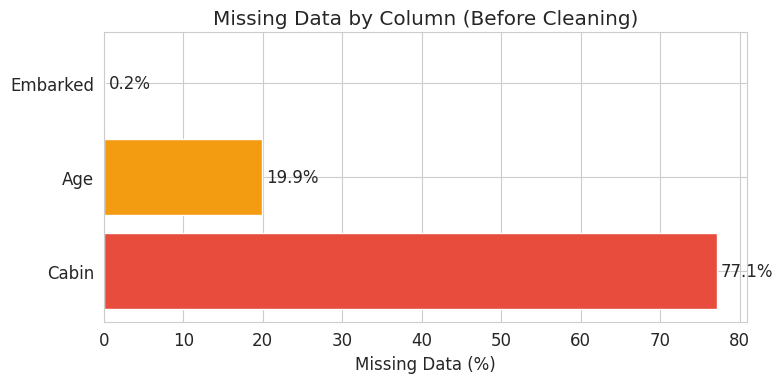


⚠ Key insight: Cabin is missing 77.1% of values — too sparse to impute reliably, so we drop it.
Age is missing 19.9% — we'll impute with the median (more robust than mean to outliers).


In [4]:
# Visualise missing data BEFORE cleaning
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print("=== Missing Values ===")
print(missing_df)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(missing_df.index, missing_df['Missing %'], color=['#e74c3c', '#f39c12', '#3498db'])
ax.set_xlabel('Missing Data (%)')
ax.set_title('Missing Data by Column (Before Cleaning)')
for i, (val, label) in enumerate(zip(missing_df['Missing %'], missing_df.index)):
    ax.text(val + 0.5, i, f'{val}%', va='center')
plt.tight_layout()
plt.show()

print("\n⚠ Key insight: Cabin is missing 77.1% of values — too sparse to impute reliably, so we drop it.")
print("Age is missing 19.9% — we'll impute with the median (more robust than mean to outliers).")

## 4. Data Cleaning

We handle missing values and remove unnecessary columns.

- **Cabin**: Dropped — 77.1% missing, not recoverable
- **Age**: Imputed with **median** (28.0 years) — more robust than mean for skewed data
- **Embarked**: Imputed with **mode** (Southampton, 'S') — only 2 values missing

In [5]:
df = df.drop(['Cabin'], axis=1)

# Use median (not mean) for Age — more robust against outliers
age_median = df['Age'].median()
df['Age'] = df['Age'].fillna(age_median)

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

print(f"Age median used for imputation: {age_median}")
print(f"Missing values remaining: {df.isnull().sum().sum()}")
print(f"\nDataset after cleaning: {df.shape[0]} rows x {df.shape[1]} columns")

Age median used for imputation: 28.0
Missing values remaining: 0

Dataset after cleaning: 891 rows x 11 columns


## 5. Feature Engineering

We create meaningful new features from existing columns:
- **Title**: Extracted from passenger name — a strong socio-economic signal (Mr, Mrs, Master, Miss, Rare)
- **FamilySize**: SibSp + Parch + 1 (total people including the passenger)
- **FamilyGroup**: Categorical grouping of family size (Solo / Small / Large)
- **AgeGroup**: Categorical life-stage buckets (Minor / Adult / Senior)

In [6]:
# --- Title ---
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
rare_titles = df['Title'].value_counts()[df['Title'].value_counts() < 10].index
df['Title'] = df['Title'].replace(rare_titles, 'Rare')
df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

print("Title distribution:")
print(df['Title'].value_counts())

# --- Family Size ---
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# --- Family Group ---  (fix: create BEFORE plotting)
df['FamilyGroup'] = pd.cut(
    df['FamilySize'],
    bins=[0, 1, 4, 20],
    labels=['Solo', 'Small (2–4)', 'Large (5+)']
)

# --- Age Group ---
def age_group(age):
    if age < 18: return 'Minor'
    elif age < 60: return 'Adult'
    else: return 'Senior'

df['AgeGroup'] = df['Age'].apply(age_group)

print("\nFamilyGroup distribution:")
print(df['FamilyGroup'].value_counts())
print("\nAgeGroup distribution:")
print(df['AgeGroup'].value_counts())

Title distribution:
Title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64

FamilyGroup distribution:
FamilyGroup
Solo           537
Small (2–4)    292
Large (5+)      62
Name: count, dtype: int64

AgeGroup distribution:
AgeGroup
Adult     752
Minor     113
Senior     26
Name: count, dtype: int64


## 6. Data Analysis & Visualisation

We now explore how each factor influences survival. Each chart is accompanied by a key takeaway.

### 6.1 Survival by Gender

Gender is one of the strongest predictors of survival — reflecting the **'women and children first'** evacuation protocol.

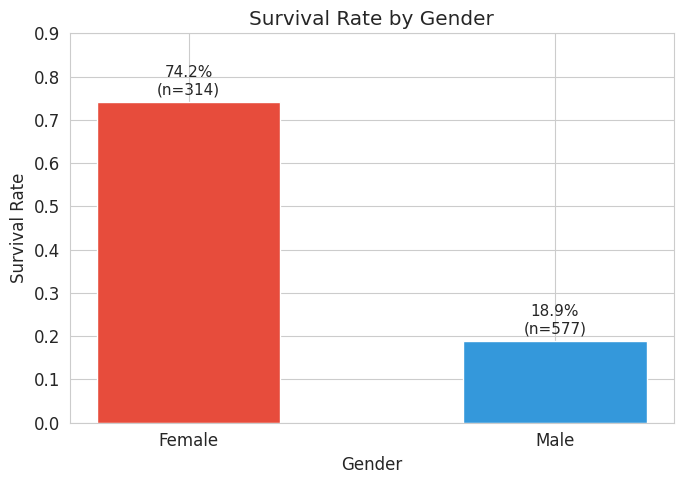


📊 Key Insight: Women survived at 74.2% vs. men at 18.9% — a gap of 55.3% (3.9x higher odds for women).


In [7]:
gender_survival = df.groupby('Sex')['Survived'].agg(['mean', 'count']).reset_index()
gender_survival.columns = ['Sex', 'SurvivalRate', 'Count']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(gender_survival['Sex'], gender_survival['SurvivalRate'],
              color=['#e74c3c', '#3498db'], edgecolor='white', width=0.5)

# Annotate bars with rate + count
for bar, row in zip(bars, gender_survival.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{row.SurvivalRate:.1%}\n(n={row.Count})', ha='center', va='bottom', fontsize=11)

ax.set_ylim(0, 0.9)
ax.set_xlabel('Gender')
ax.set_ylabel('Survival Rate')
ax.set_title('Survival Rate by Gender')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Female', 'Male'])
plt.tight_layout()
plt.show()

female_rate = gender_survival[gender_survival['Sex']=='female']['SurvivalRate'].values[0]
male_rate = gender_survival[gender_survival['Sex']=='male']['SurvivalRate'].values[0]
print(f"\n📊 Key Insight: Women survived at {female_rate:.1%} vs. men at {male_rate:.1%} — "
      f"a gap of {female_rate - male_rate:.1%} ({(female_rate/male_rate):.1f}x higher odds for women).")

### 6.2 Survival by Passenger Class

Passenger class acts as a direct proxy for **socio-economic status**. Higher-class passengers had better deck access, more proximity to lifeboats, and likely received priority during evacuation.

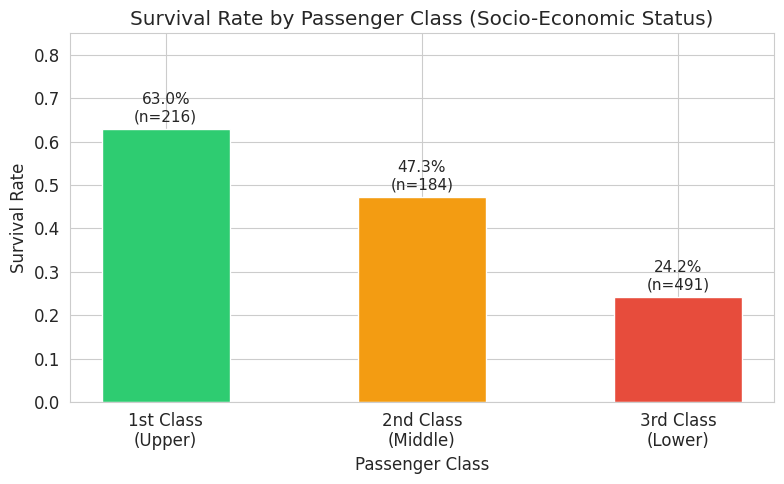


📊 Key Insight: 1st class survived at 63.0% vs. 3rd class at 24.2% — a 38.7% gap, highlighting a stark socio-economic disparity in survival.


In [8]:
class_survival = df.groupby('Pclass')['Survived'].agg(['mean', 'count']).reset_index()
class_survival.columns = ['Pclass', 'SurvivalRate', 'Count']
class_labels = {1: '1st Class\n(Upper)', 2: '2nd Class\n(Middle)', 3: '3rd Class\n(Lower)'}

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar([class_labels[c] for c in class_survival['Pclass']],
              class_survival['SurvivalRate'],
              color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='white', width=0.5)

for bar, row in zip(bars, class_survival.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{row.SurvivalRate:.1%}\n(n={row.Count})', ha='center', va='bottom', fontsize=11)

ax.set_ylim(0, 0.85)
ax.set_xlabel('Passenger Class')
ax.set_ylabel('Survival Rate')
ax.set_title('Survival Rate by Passenger Class (Socio-Economic Status)')
plt.tight_layout()
plt.show()

class1 = class_survival[class_survival['Pclass']==1]['SurvivalRate'].values[0]
class3 = class_survival[class_survival['Pclass']==3]['SurvivalRate'].values[0]
print(f"\n📊 Key Insight: 1st class survived at {class1:.1%} vs. 3rd class at {class3:.1%} — "
      f"a {class1 - class3:.1%} gap, highlighting a stark socio-economic disparity in survival.")

### 6.3 Survival by Life Stage (Age Group)

Age-based survival reflects the second part of 'women and children first' — minors had a higher survival advantage.

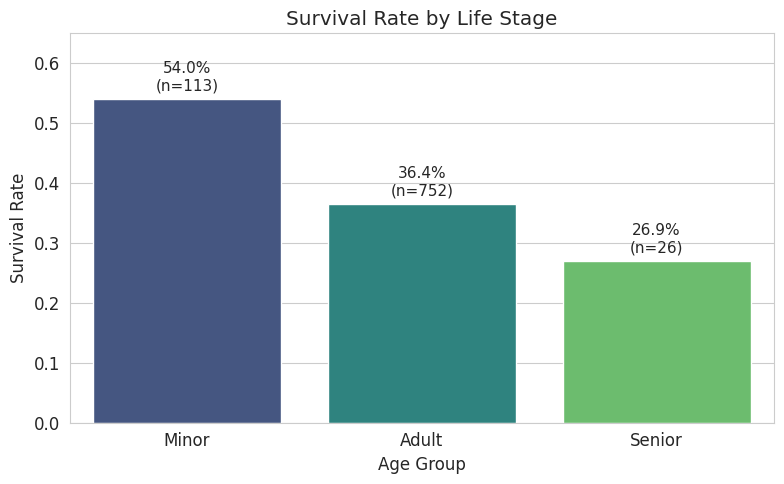


📊 Key Insight: Minors survived at 54.0%, compared to adults at 36.4%, consistent with child-priority evacuation protocols.


In [9]:
age_group_survival = df.groupby('AgeGroup')['Survived'].agg(['mean', 'count']).reset_index()
age_group_survival.columns = ['AgeGroup', 'SurvivalRate', 'Count']
# Fix display order
age_order = ['Minor', 'Adult', 'Senior']
age_group_survival['AgeGroup'] = pd.Categorical(age_group_survival['AgeGroup'], categories=age_order, ordered=True)
age_group_survival = age_group_survival.sort_values('AgeGroup')

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x='AgeGroup', y='SurvivalRate', data=age_group_survival,
            palette='viridis', hue='AgeGroup', legend=False, ax=ax)

for i, row in enumerate(age_group_survival.itertuples()):
    ax.text(i, row.SurvivalRate + 0.01, f'{row.SurvivalRate:.1%}\n(n={row.Count})',
            ha='center', va='bottom', fontsize=11)

ax.set_ylim(0, 0.65)
ax.set_xlabel('Age Group')
ax.set_ylabel('Survival Rate')
ax.set_title('Survival Rate by Life Stage')
plt.tight_layout()
plt.show()

minor_rate = age_group_survival[age_group_survival['AgeGroup']=='Minor']['SurvivalRate'].values[0]
adult_rate = age_group_survival[age_group_survival['AgeGroup']=='Adult']['SurvivalRate'].values[0]
print(f"\n📊 Key Insight: Minors survived at {minor_rate:.1%}, compared to adults at {adult_rate:.1%}, "
      f"consistent with child-priority evacuation protocols.")

### 6.4 Survival by Passenger Title

Titles reveal finer social distinctions not captured by class alone.

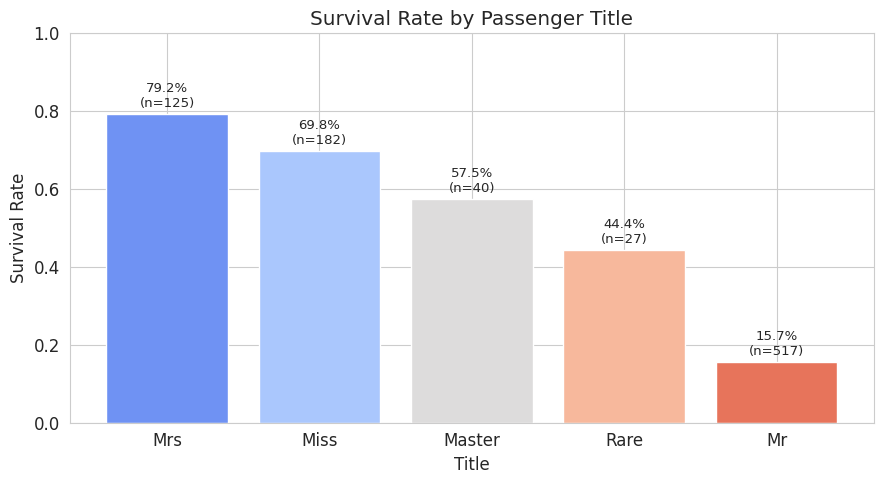


📊 Key Insight: Mrs and Miss titles had the highest survival — consistent with female priority.
   'Master' (young boys) also survived at a high rate, reflecting child priority evacuation.


In [10]:
title_survival = df.groupby('Title')['Survived'].agg(['mean', 'count']).reset_index()
title_survival.columns = ['Title', 'SurvivalRate', 'Count']
title_survival = title_survival.sort_values('SurvivalRate', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(title_survival['Title'], title_survival['SurvivalRate'],
              color=sns.color_palette('coolwarm', len(title_survival)), edgecolor='white')

for bar, row in zip(bars, title_survival.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{row.SurvivalRate:.1%}\n(n={row.Count})', ha='center', va='bottom', fontsize=9.5)

ax.set_ylim(0, 1.0)
ax.set_xlabel('Title')
ax.set_ylabel('Survival Rate')
ax.set_title('Survival Rate by Passenger Title')
plt.tight_layout()
plt.show()

print("\n📊 Key Insight: Mrs and Miss titles had the highest survival — consistent with female priority.")
print("   'Master' (young boys) also survived at a high rate, reflecting child priority evacuation.")

### 6.5 Survival by Family Group

Does travelling with family help or hurt your chances of survival?

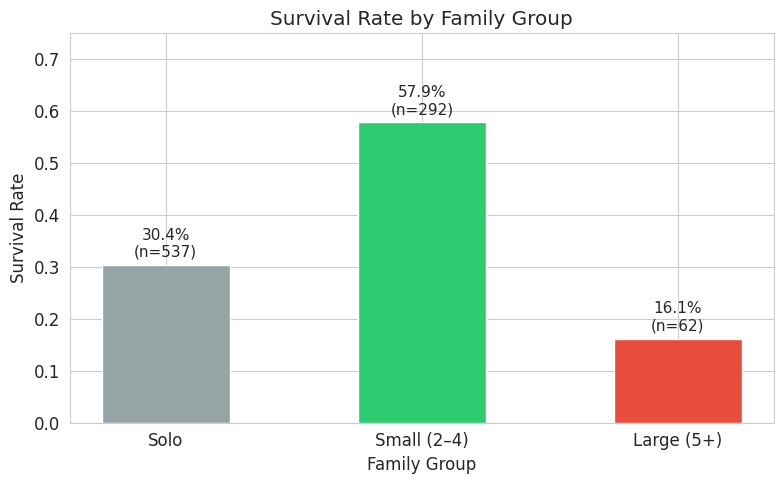


📊 Key Insight:
   Solo travellers: 30.4% survival
   Small families (2–4): 57.9% survival
   Large families (5+): 16.1% survival
   Small families appear to have had a coordination advantage, while very large groups struggled.


In [11]:
family_survival = df.groupby('FamilyGroup', observed=False)['Survived'].agg(['mean', 'count']).reset_index()
family_survival.columns = ['FamilyGroup', 'SurvivalRate', 'Count']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(family_survival['FamilyGroup'].astype(str), family_survival['SurvivalRate'],
              color=['#95a5a6', '#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)

for bar, row in zip(bars, family_survival.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{row.SurvivalRate:.1%}\n(n={row.Count})', ha='center', va='bottom', fontsize=11)

ax.set_ylim(0, 0.75)
ax.set_xlabel('Family Group')
ax.set_ylabel('Survival Rate')
ax.set_title('Survival Rate by Family Group')
plt.tight_layout()
plt.show()

solo_rate = family_survival[family_survival['FamilyGroup']=='Solo']['SurvivalRate'].values[0]
small_rate = family_survival[family_survival['FamilyGroup']=='Small (2–4)']['SurvivalRate'].values[0]
large_rate = family_survival[family_survival['FamilyGroup']=='Large (5+)']['SurvivalRate'].values[0]
print(f"\n📊 Key Insight:")
print(f"   Solo travellers: {solo_rate:.1%} survival")
print(f"   Small families (2–4): {small_rate:.1%} survival")
print(f"   Large families (5+): {large_rate:.1%} survival")
print("   Small families appear to have had a coordination advantage, while very large groups struggled.")

### 6.6 Age Distribution of Passengers

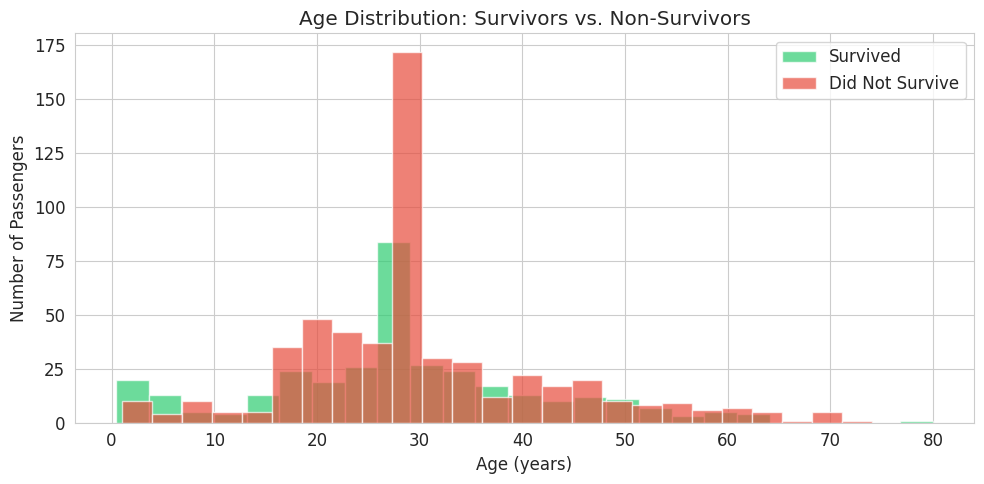

📊 Key Insight: Young children (especially under 10) show higher survival in the green bars.
   The distributions largely overlap for working-age adults, where gender and class dominate.


In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df[df['Survived']==1]['Age'], bins=25, alpha=0.7, color='#2ecc71', label='Survived')
ax.hist(df[df['Survived']==0]['Age'], bins=25, alpha=0.7, color='#e74c3c', label='Did Not Survive')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Number of Passengers')
ax.set_title('Age Distribution: Survivors vs. Non-Survivors')
ax.legend()
plt.tight_layout()
plt.show()

print("📊 Key Insight: Young children (especially under 10) show higher survival in the green bars.")
print("   The distributions largely overlap for working-age adults, where gender and class dominate.")

### 6.7 Survival Probability Matrix: Gender × Class

Combining gender and class gives us the most informative single view of survival probability. This is where the data tells its clearest story.

Survival Probability Matrix (Gender × Class):
           Female   Male
1st Class   0.968  0.369
2nd Class   0.921  0.157
3rd Class   0.500  0.135


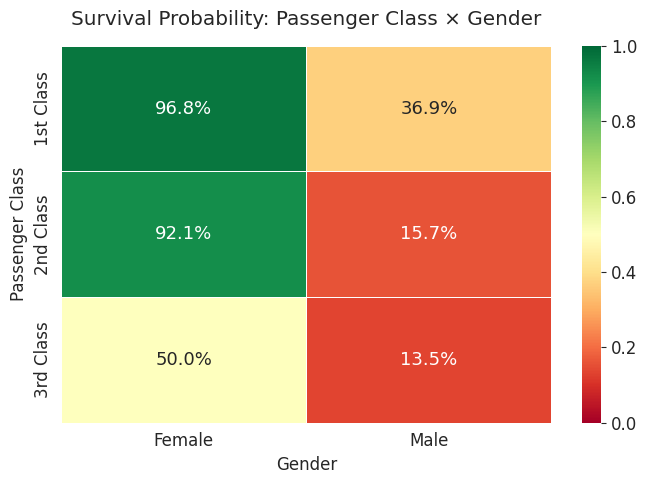


📊 Key Insight:
   Best odds: 1st class female — 96.8% survival
   Worst odds: 3rd class male — 13.5% survival
   Gap between best and worst: 83.3%


In [13]:
pivot = df.pivot_table(index='Pclass', columns='Sex', values='Survived', aggfunc='mean')
pivot.index = ['1st Class', '2nd Class', '3rd Class']
pivot.columns = ['Female', 'Male']

print("Survival Probability Matrix (Gender × Class):")
print(pivot.round(3))

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(pivot, annot=True, fmt='.1%', cmap='RdYlGn', vmin=0, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size': 13})
ax.set_title('Survival Probability: Passenger Class × Gender', pad=15)
ax.set_xlabel('Gender')
ax.set_ylabel('Passenger Class')
plt.tight_layout()
plt.show()

print("\n📊 Key Insight:")
print(f"   Best odds: 1st class female — {pivot.loc['1st Class','Female']:.1%} survival")
print(f"   Worst odds: 3rd class male — {pivot.loc['3rd Class','Male']:.1%} survival")
print(f"   Gap between best and worst: {pivot.loc['1st Class','Female'] - pivot.loc['3rd Class','Male']:.1%}")

### 6.8 Feature Correlation Heatmap

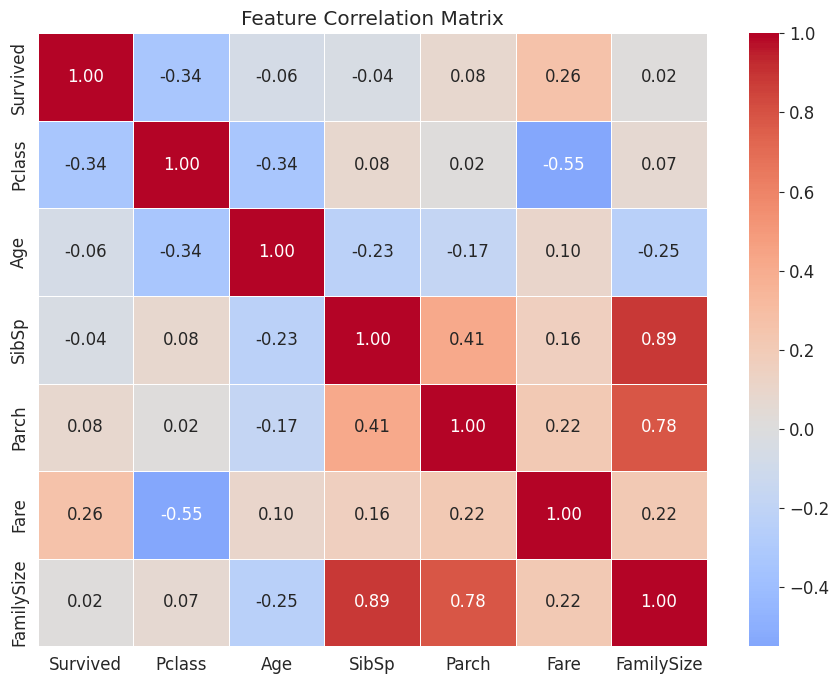


📊 Key Insight: Pclass has the strongest negative correlation with Survived (−0.34).
   Fare is positively correlated with Survived (0.26), consistent with class being a key factor.


In [14]:
numeric_df = df.select_dtypes(include=['number']).drop('PassengerId', axis=1)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

print("\n📊 Key Insight: Pclass has the strongest negative correlation with Survived (−0.34).")
print("   Fare is positively correlated with Survived (0.26), consistent with class being a key factor.")

## 7. Summary & Conclusions

### Key Findings

| Factor | Finding |
|--------|---------|
| **Gender** | Women survived at **74.2%** vs. men at **18.9%** — a 55% gap driven by evacuation protocol |
| **Class (SES)** | 1st class: **63.0%** vs. 3rd class: **24.2%** — a 38.8% socio-economic gap |
| **Age** | Minors (under 18) survived at a **higher rate** than adults, consistent with 'children first' |
| **Family Size** | Small families (2–4) had the **highest survival rate**; solo travellers and large groups fared worse |
| **Combined** | 1st class female: **96.8%** survival vs. 3rd class male: **13.5%** survival — a **83% gap** |

### Data-Driven Recommendations

**Infrastructure**: Standardise lifeboat access across all deck tiers. The ~39-point survival gap between 1st and 3rd class passengers strongly suggests that deck location and lifeboat proximity were not equitably distributed.

**Emergency Protocols**: Implement structured evacuation that accounts for family coordination. Small families (2–4 people) showed the best survival outcomes — suggesting that coordinated group evacuation offers a meaningful advantage over individuals acting alone.

**Communication**: Prioritise clear, multilingual evacuation signage for all passenger tiers. 3rd class passengers, who often spoke different languages and were furthest from lifeboats, faced the steepest survival disadvantage.

### Limitations & Next Steps
- Age was imputed for ~20% of passengers — results should be interpreted with caution for age-based conclusions
- A predictive model (e.g. logistic regression or decision tree) would quantify the relative importance of each feature
- Crew survival data is not included, which would provide additional context for the overall disaster